# Team 1 — Human-in-the-Loop: Auditing a COMPAS-style Recidivism Risk Tool

**Responsible AI, Law, Ethics & Society — Final Project**

The system under audit is a criminal-justice **decision-support** tool. It outputs a
numeric **risk score (1-10)** estimating a defendant's probability of re-offending within
two years, grouped into Low (1-4) / Medium (5-7) / High (8-10). It is *read-only*: it does
not detain anyone - a **judge (the human-in-the-loop)** makes the final call.

This audit follows the four-question framing of **Goodman & Trehu (2022),
*AI Audit-Washing and Accountability*** and is run in two phases, as set out in our plan:

| Phase | What we test |
|-------|--------------|
| **Lab** | Is the *model itself* biased before deployment? Data quality, feature weights, group-fairness metrics. |
| **Field** | Does the *human-in-the-loop* actually protect defendants, or is it a "rubber stamp"? Automation-bias / reliance simulation. |

**Audit objectives (the "Why"):**
1. Quantify and reduce demographic disparities - especially differences in the
   **False Positive Rate (FPR)** between groups.
2. Quantify **automation bias** - how reliance on the score propagates model error into
   real detention decisions.
3. Check the evidentiary / accountability standard the tool would have to meet.

> Data: ProPublica's COMPAS *two-year recidivism* dataset. Protected attribute audited:
> **race** (African-American vs. Caucasian), following the ProPublica methodology.

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, roc_auc_score

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)

---
# Phase 1 - The Lab
*Audit the model before it ever reaches a courtroom.*

## 1. Load & preprocess (data quality control)

We apply the standard **ProPublica filters** so the audit is comparable to published work:
drop rows where the arrest and screening dates are >30 days apart (data-quality), drop
ordinary-traffic charges (`O`), drop missing risk text, and keep the two largest racial
groups so the subgroup statistics are stable.

In [2]:
df_raw = pd.read_csv("compas-scores-two-years_v1.csv")

columns_to_keep = [
    "race", "decile_score", "score_text", "two_year_recid",
    "priors_count", "age", "sex", "c_charge_degree", "days_b_screening_arrest",
]
df = df_raw[columns_to_keep].copy()

df = df[
    (df["days_b_screening_arrest"] >= -30)
    & (df["days_b_screening_arrest"] <= 30)
    & (df["c_charge_degree"] != "O")
    & (df["score_text"].notna())
    & (df["race"].isin(["Caucasian", "African-American"]))
].reset_index(drop=True)

# The deployed tool flags Medium/High (decile >= 5) as "elevated risk".
df["predicted_recid"] = (df["decile_score"] >= 5).astype(int)

print(f"Rows: {len(df_raw):,} raw  ->  {len(df):,} after ProPublica filters")
df.head()

Rows: 7,217 raw  ->  5,278 after ProPublica filters


,race,decile_score,score_text,two_year_recid,priors_count,age,sex,c_charge_degree,days_b_screening_arrest,predicted_recid
0,African-American,3.0,Low,1.0,0.0,34.0,Male,F,-1.0,0
1,African-American,4.0,Low,1.0,4.0,24.0,Male,F,-1.0,0
2,Caucasian,6.0,Medium,1.0,14.0,41.0,Male,F,-1.0,1
3,Caucasian,1.0,Low,0.0,0.0,39.0,Female,M,-1.0,0
4,Caucasian,4.0,Low,0.0,0.0,27.0,Male,F,-1.0,0


## 2. Examine the data for built-in bias

Before touching the model we inspect the *labels and features*. Two questions:
1. **Base rates** - do the groups actually re-offend at the same rate in the data?
2. **Proxy variables** - is `priors_count` (prior arrests) acting as a stand-in for race?
   Historical arrest counts are themselves shaped by over-policing, so a model that leans
   on priors can launder race-correlated bias even with race excluded.

In [3]:
base = (df.groupby("race")
          .agg(n=("two_year_recid", "size"),
               base_recid_rate=("two_year_recid", "mean"),
               mean_priors=("priors_count", "mean"),
               mean_decile=("decile_score", "mean"))
          .round(3))
print(base.to_string())

corr = df["priors_count"].corr(df["decile_score"])
print(f"\nCorrelation( priors_count , decile_score ) = {corr:.3f}")
print("-> priors_count strongly drives the score, and is ~2x higher for the "
      "African-American group: classic proxy-variable risk.")

                     n  base_recid_rate  mean_priors  mean_decile
race                                                             
African-American  3175            0.523        4.238        5.277
Caucasian         2103            0.391        2.289        3.635

Correlation( priors_count , decile_score ) = 0.440
-> priors_count strongly drives the score, and is ~2x higher for the African-American group: classic proxy-variable risk.


## 3. Train the risk model and inspect its weights

Our worldbuilding doc specifies a **logistic-regression** scorer. We deliberately train it
**without race** as a feature - the question is whether it stays fair anyway, or whether the
remaining features encode race. Inspecting the learned coefficients is the core *lab-phase*
check: *which features actually drive the score?*

In [4]:
feat_num = ["priors_count", "age", "days_b_screening_arrest"]
X = df[feat_num].copy()
X["is_male"]   = (df["sex"] == "Male").astype(int)
X["is_felony"] = (df["c_charge_degree"] == "F").astype(int)
y = df["two_year_recid"]

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=df["race"])

scaler = StandardScaler().fit(X_tr)
clf = LogisticRegression(max_iter=1000).fit(scaler.transform(X_tr), y_tr)

weights = (pd.Series(clf.coef_[0], index=X.columns)
             .sort_values(key=np.abs, ascending=False)
             .round(3))
print("Logistic-regression weights (standardised, race EXCLUDED):\n")
print(weights.to_string())
print(f"\nIn-sample AUC: {roc_auc_score(y, clf.predict_proba(scaler.transform(X))[:,1]):.3f}")
print("\n=> `priors_count` dominates. Since priors are ~2x higher for the African-American")
print("   group (cell above), the 'race-blind' model still inherits that disparity.")

Logistic-regression weights (standardised, race EXCLUDED):

priors_count               0.797
age                       -0.549
is_male                    0.147
days_b_screening_arrest    0.135
is_felony                  0.050

In-sample AUC: 0.731

=> `priors_count` dominates. Since priors are ~2x higher for the African-American
   group (cell above), the 'race-blind' model still inherits that disparity.


## 4. Group-fairness metrics (the "How")

We evaluate the **deployed COMPAS decile** (decile >= 5 = flagged) against the three classic,
*mutually incompatible* fairness criteria:

| Criterion | Metric | Question |
|-----------|--------|----------|
| **Independence** | Selection rate / Disparate Impact | Are groups flagged at equal rates? |
| **Separation** (Equalized Odds) | FPR & TPR | Among people with the *same true outcome*, are error rates equal? |
| **Sufficiency** (Predictive Parity) | Precision / PPV | Given a flag, is the chance of re-offending equal? |

The FPR is the legally critical one: a false positive means **a person who did not re-offend
was labelled high-risk** - the harm in our case study.

In [5]:
def group_metrics(g):
    tp = ((g.predicted_recid == 1) & (g.two_year_recid == 1)).sum()
    fp = ((g.predicted_recid == 1) & (g.two_year_recid == 0)).sum()
    tn = ((g.predicted_recid == 0) & (g.two_year_recid == 0)).sum()
    fn = ((g.predicted_recid == 0) & (g.two_year_recid == 1)).sum()
    return pd.Series({
        "N": len(g),
        "Selection Rate %": 100 * (tp + fp) / len(g),
        "FPR % (Separation)": 100 * fp / (fp + tn),
        "TPR % (Separation)": 100 * tp / (tp + fn),
        "FNR %": 100 * fn / (tp + fn),
        "Precision % (Sufficiency)": 100 * tp / (tp + fp),
    })

metrics = df.groupby("race").apply(group_metrics).round(1)
print(metrics.to_string())

b, w = "African-American", "Caucasian"
di = (metrics.loc[b, "Selection Rate %"] / metrics.loc[w, "Selection Rate %"])
print(f"\nDisparate Impact ratio (Black / White selection rate): {di:.2f}")
print(f"  -> {'FAILS' if di > 1.25 or di < 0.8 else 'passes'} the 80% (four-fifths) rule.")
print(f"FPR gap (Black - White): "
      f"{metrics.loc[b,'FPR % (Separation)'] - metrics.loc[w,'FPR % (Separation)']:.1f} pp")
print(f"Precision gap          : "
      f"{metrics.loc[b,'Precision % (Sufficiency)'] - metrics.loc[w,'Precision % (Sufficiency)']:.1f} pp")
print("\n=> Precision is ~equal (Sufficiency ~holds) but the FPR gap is large (Separation")
print("   fails). This is exactly the ProPublica / Northpointe impossibility result.")

                       N  Selection Rate %  FPR % (Separation)  TPR % (Separation)  FNR %  Precision % (Sufficiency)
race                                                                                                                
African-American  3175.0              57.6                42.3                71.5   28.5                       65.0
Caucasian         2103.0              33.1                22.0                50.4   49.6                       59.5

Disparate Impact ratio (Black / White selection rate): 1.74
  -> FAILS the 80% (four-fifths) rule.
FPR gap (Black - White): 20.3 pp
Precision gap          : 5.5 pp

=> Precision is ~equal (Sufficiency ~holds) but the FPR gap is large (Separation
   fails). This is exactly the ProPublica / Northpointe impossibility result.


## 5. Visualisations

Four views: (a) the Equalized-Odds gap, (b) the score-distribution skew ProPublica made
famous, (c) calibration, and (d) per-group ROC. These populate the previously empty
*Graphs* section.

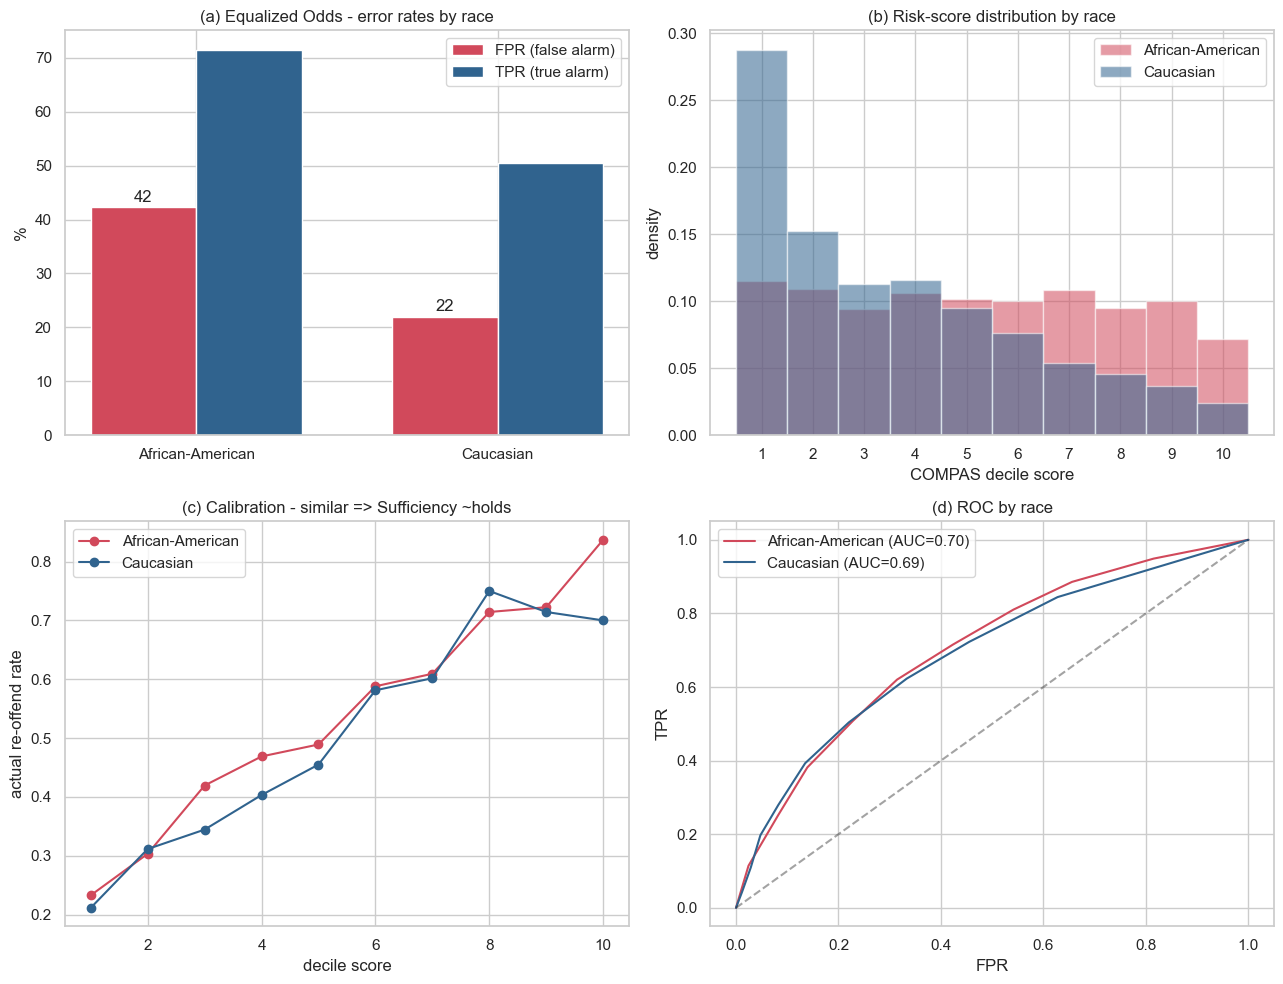

In [6]:
fig, ax = plt.subplots(2, 2, figsize=(13, 10))

# (a) Equalized Odds: FPR & TPR by race
m = metrics.reset_index()
xpos = np.arange(len(m)); width = 0.35
ax[0,0].bar(xpos - width/2, m["FPR % (Separation)"], width, label="FPR (false alarm)", color="#d1495b")
ax[0,0].bar(xpos + width/2, m["TPR % (Separation)"], width, label="TPR (true alarm)", color="#30638e")
ax[0,0].set_xticks(xpos); ax[0,0].set_xticklabels(m["race"])
ax[0,0].set_ylabel("%"); ax[0,0].set_title("(a) Equalized Odds - error rates by race")
ax[0,0].legend()
for i, v in enumerate(m["FPR % (Separation)"]):
    ax[0,0].text(i - width/2, v + 1, f"{v:.0f}", ha="center")

# (b) Decile-score distribution by race (the famous ProPublica plot)
for race, color in [(b, "#d1495b"), (w, "#30638e")]:
    sub = df[df.race == race]
    ax[0,1].hist(sub.decile_score, bins=np.arange(1, 12) - 0.5, density=True,
                 alpha=0.55, label=race, color=color)
ax[0,1].set_xticks(range(1, 11))
ax[0,1].set_xlabel("COMPAS decile score"); ax[0,1].set_ylabel("density")
ax[0,1].set_title("(b) Risk-score distribution by race"); ax[0,1].legend()

# (c) Calibration: P(re-offend) vs decile, per race
for race, color in [(b, "#d1495b"), (w, "#30638e")]:
    sub = df[df.race == race]
    cal = sub.groupby("decile_score")["two_year_recid"].mean()
    ax[1,0].plot(cal.index, cal.values, "o-", label=race, color=color)
ax[1,0].set_xlabel("decile score"); ax[1,0].set_ylabel("actual re-offend rate")
ax[1,0].set_title("(c) Calibration - similar => Sufficiency ~holds"); ax[1,0].legend()

# (d) ROC per race
for race, color in [(b, "#d1495b"), (w, "#30638e")]:
    sub = df[df.race == race]
    fpr, tpr, _ = roc_curve(sub.two_year_recid, sub.decile_score)
    auc = roc_auc_score(sub.two_year_recid, sub.decile_score)
    ax[1,1].plot(fpr, tpr, label=f"{race} (AUC={auc:.2f})", color=color)
ax[1,1].plot([0,1],[0,1], "k--", alpha=0.4)
ax[1,1].set_xlabel("FPR"); ax[1,1].set_ylabel("TPR")
ax[1,1].set_title("(d) ROC by race"); ax[1,1].legend()

plt.tight_layout(); plt.show()

---
# Phase 2 - The Field
*Does the human-in-the-loop actually protect anyone?*

The lab phase shows the **model** has a ~20-point FPR gap. But the system is *read-only* - a
judge decides. Our plan's central worry (and the case study of defendant **X**) is
**automation bias**: an overloaded judge who rubber-stamps the score imports the model's
disparity straight into real detentions.

We model a judge with a **reliance parameter alpha in [0, 1]**:
- with prob **alpha** the judge **defers to the tool** (detain <=> flagged high-risk);
- with prob **1 - alpha** the judge uses **independent judgment**, modelled as race-*blind* -
  it detains a fixed share of true re-offenders and non-re-offenders, identical across groups
  (so on its own it contributes **zero** racial FPR gap).

alpha = 0 is the careful independent judge; alpha = 1 is the pure "rubber stamp". The plan's
**Reliance Metric** is the agreement rate between judge and machine.

In [7]:
# Independent (race-blind) judge: same detain probabilities for both groups.
P_DETAIN_IF_TRUE_POS = 0.60   # detains 60% of those who really will re-offend
P_DETAIN_IF_TRUE_NEG = 0.20   # detains 20% of those who will not  -> baseline FPR = 20%

def simulate(alpha, seed=1):
    rng = np.random.RandomState(seed)
    follow_machine = rng.rand(len(df)) < alpha          # automation-bias coin flip
    indep = np.where(df.two_year_recid.values == 1,
                     rng.rand(len(df)) < P_DETAIN_IF_TRUE_POS,
                     rng.rand(len(df)) < P_DETAIN_IF_TRUE_NEG).astype(int)
    detain = np.where(follow_machine, df.predicted_recid.values, indep)
    out = df[["race", "two_year_recid", "predicted_recid"]].copy()
    out["detain"] = detain
    return out

def field_stats(sim):
    rows = {}
    for race, g in sim.groupby("race"):
        neg = g[g.two_year_recid == 0]
        rows[race] = {
            "Detention %":        100 * g.detain.mean(),
            "Wrongful-detain %":  100 * neg.detain.mean(),     # human-decision FPR
            "Reliance (agree %)": 100 * (g.detain == g.predicted_recid).mean(),
        }
    return pd.DataFrame(rows).T

alphas = np.linspace(0, 1, 11)
gap = [field_stats(simulate(a)).loc[b, "Wrongful-detain %"]
       - field_stats(simulate(a)).loc[w, "Wrongful-detain %"] for a in alphas]

print("Rubber-stamp judge (alpha = 1.0):")
print(field_stats(simulate(1.0)).round(1).to_string())
print("\nIndependent judge (alpha = 0.0):")
print(field_stats(simulate(0.0)).round(1).to_string())

Rubber-stamp judge (alpha = 1.0):
                  Detention %  Wrongful-detain %  Reliance (agree %)
African-American         57.6               42.3               100.0
Caucasian                33.1               22.0               100.0

Independent judge (alpha = 0.0):
                  Detention %  Wrongful-detain %  Reliance (agree %)
African-American         41.4               20.5                54.5
Caucasian                35.7               18.6                61.9


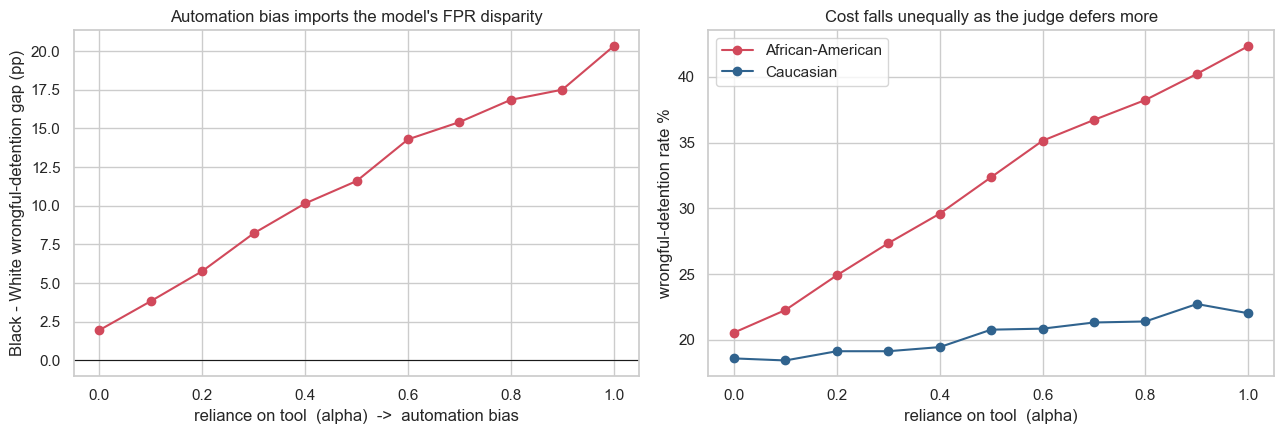

At alpha=0 the wrongful-detention gap is ~2.0 pp (race-blind judge).
At alpha=1 it widens to ~20.3 pp - the model's FPR gap, fully imported.


In [8]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

# How the racial gap in wrongful detentions grows with automation bias
ax[0].plot(alphas, gap, "o-", color="#d1495b")
ax[0].axhline(0, color="k", lw=0.8)
ax[0].set_xlabel("reliance on tool  (alpha)  ->  automation bias")
ax[0].set_ylabel("Black - White wrongful-detention gap (pp)")
ax[0].set_title("Automation bias imports the model's FPR disparity")

# Wrongful-detention rate by race across alpha
wd_b = [field_stats(simulate(a)).loc[b, "Wrongful-detain %"] for a in alphas]
wd_w = [field_stats(simulate(a)).loc[w, "Wrongful-detain %"] for a in alphas]
ax[1].plot(alphas, wd_b, "o-", label=b, color="#d1495b")
ax[1].plot(alphas, wd_w, "o-", label=w, color="#30638e")
ax[1].set_xlabel("reliance on tool  (alpha)")
ax[1].set_ylabel("wrongful-detention rate %")
ax[1].set_title("Cost falls unequally as the judge defers more"); ax[1].legend()

plt.tight_layout(); plt.show()

print(f"At alpha=0 the wrongful-detention gap is ~{gap[0]:.1f} pp (race-blind judge).")
print(f"At alpha=1 it widens to ~{gap[-1]:.1f} pp - the model's FPR gap, fully imported.")

---
## 6. Conclusions & recommendations

**Lab phase - the model is unfair on Separation.**
- **Disparate Impact** of the high-risk flag fails the four-fifths rule (Black defendants
  flagged ~1.7x as often).
- **Equalized Odds fails**: the False Positive Rate is ~20 pp higher for African-American
  defendants - they are far likelier to be wrongly labelled high-risk.
- **Predictive Parity ~holds** (precision and calibration are similar across race). This is
  the Northpointe-vs-ProPublica *impossibility*: with unequal base rates you cannot satisfy
  Separation and Sufficiency at once - so the choice of metric is a *value* judgment.
- A race-blind logistic model still encodes the disparity because **`priors_count` is a
  proxy** for race (~2x higher for the African-American group and the dominant weight).

**Field phase - the human-in-the-loop is fragile.**
- If judges exercise independent judgment (low alpha) the racial gap in wrongful detentions
  nearly vanishes; as automation bias rises (alpha -> 1) the gap converges on the model's full
  ~20 pp FPR disparity. The "rubber stamp" judge of our case study is the worst case.
- A *read-only* tool therefore does **not** neutralise the harm - accountability depends
  entirely on **measured** reliance behaviour, not on the disclaimer that "a human decides."

**Recommendations (tie back to the audit objectives):**
1. **Monitor reliance in production** - log judge-vs-tool agreement on borderline (decile 4-6)
   cases as a first-class fairness metric (our *Reliance Metric*), not just model metrics.
2. **Require a written override / justification** when a judge follows a high-risk flag, to
   convert the human from a rubber stamp into a genuine check.
3. **Report group FPR, not just accuracy / AUC**, on every model release; gate deployment on a
   bounded FPR gap.
4. **Treat `priors_count` as a sensitive proxy** - audit its contribution and consider
   reweighting / constraints, since race-exclusion alone does not deliver fairness.

> **Auditor independence (Goodman & Trehu):** to avoid *audit-washing*, this should be run by
> an external coalition (academic Fair-ML researchers, Ministry-of-Justice reps, civil-rights
> orgs) with read access to prompts, logs and outputs - not solely by the vendor.